In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# explanatory analysis
Load data CRMLSListing202602.csv
Load data CRMLSSold202602


In [2]:
df_listing = pd.read_csv("data/mergedListing_24_26.csv")
print(df_listing.head()) # First 5 rows


C:\Users\14012\AppData\Local\Temp\ipykernel_140752\1072340040.py:1: DtypeWarning: Columns (0: ListAgentEmail, 1: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  df_listing = pd.read_csv("data/mergedListing_24_26.csv")


   OriginalListPrice  ListingKey                        ListAgentEmail  \
0            90000.0  1075010398                miriamlara03@gmail.com   
1          1500000.0  1074974457                  janelle@judsonre.com   
2          1340000.0  1074973329                    haleh360@Gmail.com   
3          2500000.0  1074954552  Reneechen@yourhomesoldguaranteed.com   
4          3150000.0  1074936537                      anader@dppre.com   

  CloseDate  ClosePrice ListAgentFirstName ListAgentLastName   Latitude  \
0       NaN         NaN             Miriam              Lara  34.097939   
1       NaN         NaN            Janelle            Judson  33.121241   
2       NaN         NaN              Haleh       Dowlatshahi  34.052207   
3       NaN         NaN              Renee              Chen  33.496363   
4       NaN         NaN           Margaret             Nader  34.119345   

    Longitude                UnparsedAddress  ... MainLevelBedrooms  \
0 -117.909653                1045

In [3]:
print(df_listing.shape)
print(df_listing.columns)# shape of listing

(852963, 84)
Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
       'ListingId', 'BathroomsTotalI

In [4]:
df_sold = pd.read_csv("data/merged_sold_24_26.csv")
print(df_sold.head())# First 5 rows of sold


C:\Users\14012\AppData\Local\Temp\ipykernel_140752\784731106.py:1: DtypeWarning: Columns (0: BuyerAgentAOR, 1: ListAgentAOR, 2: WaterfrontYN, 3: ListAgentEmail, 4: OriginatingSystemName, 5: OriginatingSystemSubName, 6: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sold = pd.read_csv("data/merged_sold_24_26.csv")


              BuyerAgentAOR              ListAgentAOR          Flooring  \
0               Mlslistings               Mlslistings  Carpet,Tile,Wood   
1                HighDesert                HighDesert               NaN   
2              OrangeCounty              OrangeCounty               NaN   
3             InlandValleys             InlandValleys               NaN   
4  SouthwestRiversideCounty  SouthwestRiversideCounty               NaN   

  ViewYN WaterfrontYN BasementYN PoolPrivateYN  OriginalListPrice  ListingKey  \
0   True          NaN        NaN         False           499000.0   551985747   
1    NaN          NaN        NaN           NaN                0.0   535486633   
2   True          NaN        NaN           NaN            75000.0   529986282   
3   True          NaN        NaN           NaN           199000.0   529618166   
4   True          NaN        NaN           NaN            19500.0   522614340   

               ListAgentEmail  ... PostalCode  AssociationFee 

In [5]:
print(df_sold.shape) # shape of sold
print(df_sold.columns)

(591733, 84)
Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalIntege

## Check Missing

In [6]:
missing_pct = df_listing.isnull().sum() / df_listing.shape[0] *100
missing_df = missing_pct.reset_index()
missing_df.columns = ["column", "percent_missing"]
missing_df = missing_df.sort_values("percent_missing", ascending=False) # sort from high to low

# mark columns with >90% missing
missing_df["high_missing"]= missing_df["percent_missing"]>90

# get list of columns with >90% missing
high_missing_cols = missing_df.loc[missing_df["high_missing"], "column"].tolist()

# print as string output
high_missing_str = ", ".join(high_missing_cols)
print("Variables with more than 90% missing:")
print(high_missing_str)

# define colors: red if >90%, otherwise blue
colors = ["red" if flag else "#9ecae1" for flag in missing_df["high_missing"]]

Variables with more than 90% missing:
ElementarySchoolDistrict, CoveredSpaces, AboveGradeFinishedArea, FireplacesTotal, MiddleOrJuniorSchoolDistrict, TaxYear, BelowGradeFinishedArea, BusinessType, TaxAnnualAmount, CoBuyerAgentFirstName, BuilderName, LotSizeDimensions, ElementarySchool, MiddleOrJuniorSchool


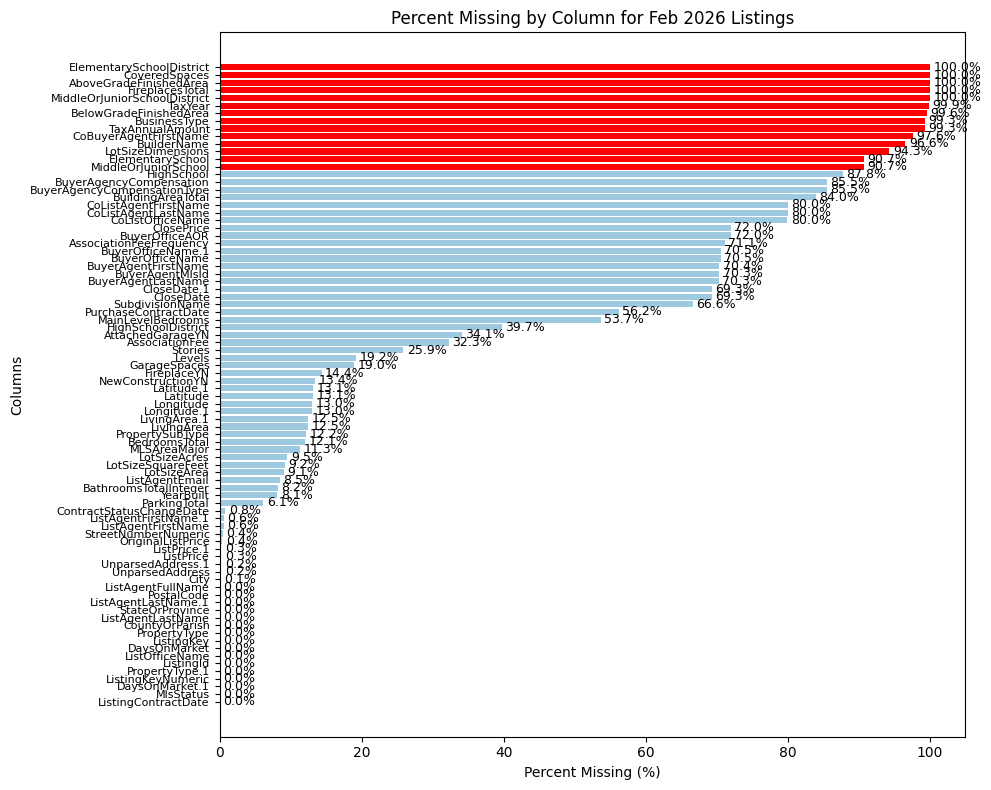

In [7]:

# plot
plt.figure(figsize=(10, 8))
ax = plt.barh(missing_df["column"], missing_df["percent_missing"], color=colors)

# add text labels
for i, v in enumerate(missing_df["percent_missing"]):
    plt.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)

plt.xlabel("Percent Missing (%)")
plt.ylabel("Columns")
plt.title("Percent Missing by Column for Feb 2026 Listings")
plt.yticks(fontsize=8)
plt.gca().invert_yaxis()   # keep highest missing at top
plt.tight_layout()
plt.show()



In [8]:
missing_pct_sold = df_sold.isnull().sum() / df_sold.shape[0] *100
missing_df_sold = missing_pct_sold.reset_index()
missing_df_sold.columns = ["column", "percent_missing"]
missing_df_sold = missing_df_sold.sort_values("percent_missing", ascending=False) # sort from high to low

# mark columns with >90% missing
missing_df_sold["high_missing"]= missing_df_sold["percent_missing"]>90

# get list of columns with >90% missing
high_missing_cols_sold = missing_df_sold.loc[missing_df_sold["high_missing"], "column"].tolist()

# print as string output
high_missing_str_sold = ", ".join(high_missing_cols_sold)
print("Variables with more than 90% missing:")
print(high_missing_str_sold)

# define colors: red if >90%, otherwise blue
colors_sold = ["red" if flag else "#9ecae1" for flag in missing_df_sold["high_missing"]]



Variables with more than 90% missing:
ElementarySchoolDistrict, CoveredSpaces, FireplacesTotal, AboveGradeFinishedArea, MiddleOrJuniorSchoolDistrict, WaterfrontYN, TaxYear, BusinessType, TaxAnnualAmount, BelowGradeFinishedArea, BasementYN, BuilderName, LotSizeDimensions, CoBuyerAgentFirstName


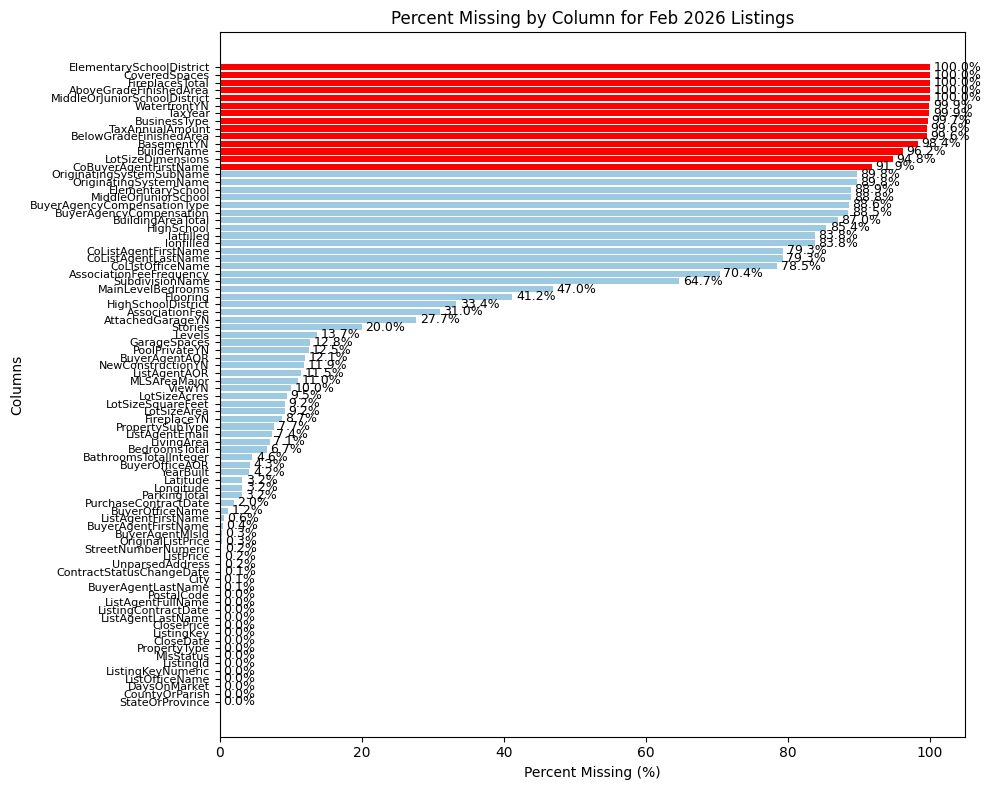

In [9]:

# plot
plt.figure(figsize=(10, 8))
ax = plt.barh(missing_df_sold["column"], missing_df_sold["percent_missing"], color=colors_sold)

# add text labels
for i, v in enumerate(missing_df_sold["percent_missing"]):
    plt.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)

plt.xlabel("Percent Missing (%)")
plt.ylabel("Columns")
plt.title("Percent Missing by Column for Feb 2026 Listings")
plt.yticks(fontsize=8)
plt.gca().invert_yaxis()   # keep highest missing at top
plt.tight_layout()
plt.show()

The categories with less missing percent is probably more important for people who wants to buy the listing.

## For variables missing more than 90%, we delete the column

if a variable is missing more than 90% in one dataset, we also delete it in the other one to keep the consistency in later analysis.

In [10]:
# ======================= SOLD =========================

# delete columns with more than 90% missing
df_sold_cleaned = df_sold.drop(columns=high_missing_cols_sold)
df_sold_cleaned = df_sold.drop(columns=high_missing_cols, errors="ignore")


# ========================LISTING =====================
# delete columns with more than 90% missing
df_listing_cleaned = df_listing.drop(columns=high_missing_cols)
df_listing_cleaned = df_sold.drop(columns=high_missing_cols_sold, errors="ignore")

# Numeric Distribution Review

Analyze the distribution of key numeric fields: **ClosePrice, ListPrice, OriginalListPrice, LivingArea,
LotSizeAcres, BedroomsTotal, BathroomsTotalInteger, DaysOnMarket, and YearBuilt**. \
For each field,
generate **histograms**, **boxplots**, and **percentile summaries**, and identify extreme **outliers** for later handling.

#### First check these variables are in both datasets

In [11]:
cols_to_check = [
    "ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea",
    "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger",
    "DaysOnMarket", "YearBuilt"
]

missing_sold = [col for col in cols_to_check if col not in df_sold_cleaned.columns]

missing_listing = [col for col in cols_to_check if col not in df_listing_cleaned.columns]

print("Missing columns in df_sold_cleaned:")
print(missing_sold if missing_sold else "None")

print("\nMissing columns in df_listing_cleaned:")
print(missing_listing if missing_listing else "None")

Missing columns in df_sold_cleaned:
None

Missing columns in df_listing_cleaned:
None


#### Set up the analysis function for all of them

In [40]:
def analyze_numeric_field(df, col):
    print("=" * 70)
    print(f"Analysis for: {col}")
    print("=" * 70)

    # Convert to numeric just in case
    x = pd.to_numeric(df[col], errors="coerce")

    # Percentile summary
    percentiles = x.quantile([
        0.00, 0.01, 0.05, 0.10, 0.25,
        0.50, 0.75, 0.90, 0.95, 0.99, 1.00
    ])

    print("\nPercentile summary:")
    print(percentiles)

    # IQR outlier rule
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(x < lower_bound) | (x > upper_bound)].copy()

    print("\nIQR outlier bounds:")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")

    print("\nNumber of outliers:")
    print(outliers.shape[0])

    print("\nOutlier percentage:")
    print(round(outliers.shape[0] / df.shape[0] * 100, 2), "%")

    # Extreme outliers using 1st and 99th percentiles
    p1 = x.quantile(0.01)
    p99 = x.quantile(0.99)

    extreme_outliers = df[(x < p1) | (x > p99)].copy()

    print("\nExtreme outlier bounds based on 1st and 99th percentiles:")
    print(f"1st percentile: {p1}")
    print(f"99th percentile: {p99}")

    print("\nNumber of extreme outliers:")
    print(extreme_outliers.shape[0])

    print("\nLowest 10 values:")
    print(df.loc[x.nsmallest(10).index, [col]])

    print("\nHighest 10 values:")
    print(df.loc[x.nlargest(10).index, [col]])

    # Histogram
    plt.figure(figsize=(8, 5))
    sns.histplot(x.dropna(), bins=50, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # Boxplot
    plt.figure(figsize=(8, 2.5))
    sns.boxplot(x=x)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

    return {
        "percentiles": percentiles,
        "iqr_outliers": outliers,
        "extreme_outliers": extreme_outliers
    }
def analyze_numeric_field_log_hist(df, col):
    print("=" * 70)
    print(f"Analysis for: {col}")
    print("=" * 70)

    # Convert to numeric just in case
    x = pd.to_numeric(df[col], errors="coerce")

    # Basic missing info
    print("\nMissing values:")
    print(x.isna().sum())

    print("\nBasic summary:")
    print(x.describe())

    # Percentile summary
    percentiles = x.quantile([
        0.00, 0.01, 0.05, 0.10, 0.25,
        0.50, 0.75, 0.90, 0.95, 0.99, 1.00
    ])

    print("\nPercentile summary:")
    print(percentiles)

    # IQR outlier rule
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    iqr_outliers = df[(x < lower_bound) | (x > upper_bound)].copy()

    print("\nIQR outlier bounds:")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")

    print("\nNumber of IQR outliers:")
    print(iqr_outliers.shape[0])

    print("\nIQR outlier percentage:")
    print(round(iqr_outliers.shape[0] / df.shape[0] * 100, 2), "%")

    # Extreme outliers using 1st and 99th percentiles
    p1 = x.quantile(0.01)
    p99 = x.quantile(0.99)

    extreme_outliers = df[(x < p1) | (x > p99)].copy()

    print("\nExtreme outlier bounds based on 1st and 99th percentiles:")
    print(f"1st percentile: {p1}")
    print(f"99th percentile: {p99}")

    print("\nNumber of extreme outliers:")
    print(extreme_outliers.shape[0])

    print("\nLowest 10 values:")
    print(df.loc[x.nsmallest(10).index, [col]])

    print("\nHighest 10 values:")
    print(df.loc[x.nlargest(10).index, [col]])

    # Histogram
    plt.figure(figsize=(8, 5))

    if col == "YearBuilt":
        sns.histplot(x.dropna(), bins=50, kde=True)
        plt.xlim(1775, 2026)
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
    else:
        x_positive = x[x > 0]
        sns.histplot(x_positive.dropna(), bins=50, kde=True)
        plt.xscale("log")
        plt.title(f"Histogram of {col} with Log Scale")
        plt.xlabel(col)

    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # Boxplot
    plt.figure(figsize=(8, 2.5))
    sns.boxplot(x=x.dropna())
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

    return {
        "percentiles": percentiles,
        "iqr_outliers": iqr_outliers,
        "extreme_outliers": extreme_outliers
    }

## ClosePrice

Analysis for: ClosePrice

Missing values:
7

Basic summary:
count    5.917260e+05
mean     8.740147e+05
std      5.229021e+06
min      0.000000e+00
25%      5.250000e+04
50%      6.297275e+05
75%      1.070000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64

Percentile summary:
0.00            0.0
0.01         1750.0
0.05         2695.0
0.10         3495.0
0.25        52500.0
0.50       629727.5
0.75      1070000.0
0.90      1780107.5
0.95      2500000.0
0.99      4995000.0
1.00    989500000.0
Name: ClosePrice, dtype: float64

IQR outlier bounds:
Lower bound: -1473750.0
Upper bound: 2596250.0

Number of IQR outliers:
27498

IQR outlier percentage:
4.65 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 1750.0
99th percentile: 4995000.0

Number of extreme outliers:
11710

Lowest 10 values:
        ClosePrice
19564          0.0
35389          0.0
51740          0.0
83554          0.0
122202         0.0
140642         0.0
140648         0.0
182355     

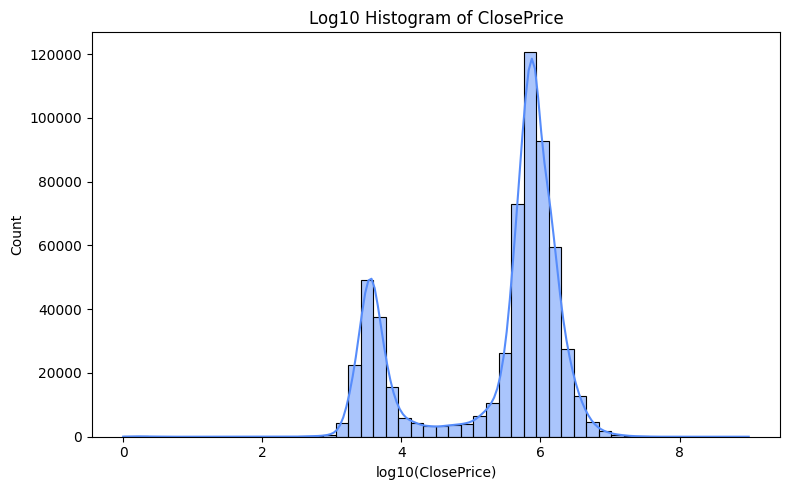

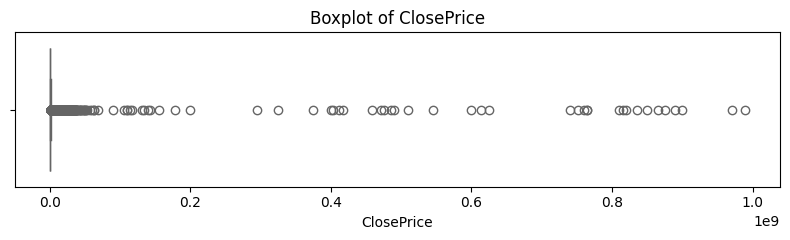

Analysis for: ClosePrice

Missing values:
7

Basic summary:
count    5.917260e+05
mean     8.740147e+05
std      5.229021e+06
min      0.000000e+00
25%      5.250000e+04
50%      6.297275e+05
75%      1.070000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64

Percentile summary:
0.00            0.0
0.01         1750.0
0.05         2695.0
0.10         3495.0
0.25        52500.0
0.50       629727.5
0.75      1070000.0
0.90      1780107.5
0.95      2500000.0
0.99      4995000.0
1.00    989500000.0
Name: ClosePrice, dtype: float64

IQR outlier bounds:
Lower bound: -1473750.0
Upper bound: 2596250.0

Number of IQR outliers:
27498

IQR outlier percentage:
4.65 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 1750.0
99th percentile: 4995000.0

Number of extreme outliers:
11710

Lowest 10 values:
        ClosePrice
19564          0.0
35389          0.0
51740          0.0
83554          0.0
122202         0.0
140642         0.0
140648         0.0
182355     

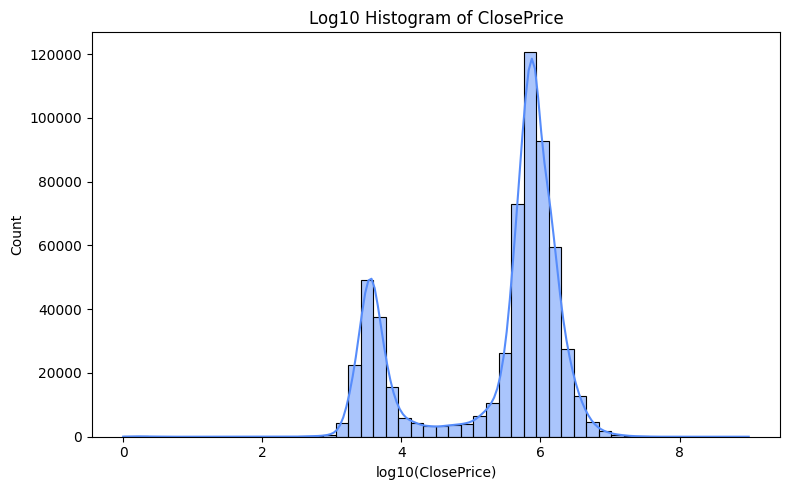

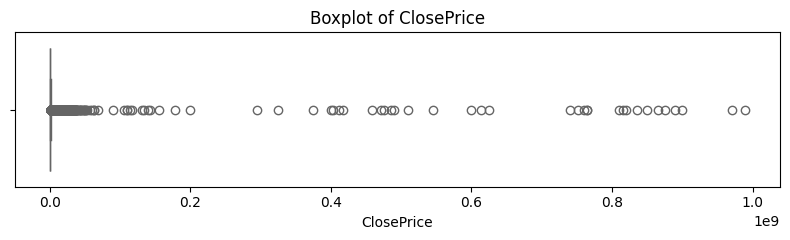

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
475578,PacificWest,PacificWest,NaN,True,True,979000.0,1133720285,Bryan@ModernHistorics.com,2025-10-31,989500000.0,...,William S. Hart Union,91355,0.0,10256.0,NaN,NaN,NaN,NaN,NaN,NaN
350917,NorthSanDiegoCounty,NorthSanDiegoCounty,NaN,True,False,998900.0,1100948167,realestate.superior@gmail.com,2025-04-11,970000000.0,...,Sweetwater Union,91913,89.0,5344.0,NaN,NaN,NaN,NaN,NaN,NaN
400439,SanLuisObispoCoastal,SanLuisObispoCoastal,"Brick,Carpet,Stone,Wood",True,False,15500000.0,1076630163,terri@terribender.com,2025-06-27,900000000.0,...,Bakersfield City,93287,0.0,13072356.0,NaN,NaN,NaN,NaN,NaN,NaN
461546,NorthSanDiegoCounty,NorthSanDiegoCounty,"Carpet,Laminate,Tile",True,False,899850.0,1118793238,saghomes@gmail.com,2025-09-15,890000000.0,...,Poway Unified,92127,331.0,46609.2,NaN,NaN,NaN,NaN,NaN,NaN
447370,PacificSouthwest,PacificSouthwest,NaN,False,False,875000.0,1136956787,dushaundf@gmail.com,2025-09-25,875000000.0,...,San Diego Unified,92117,0.0,8900.0,NaN,NaN,NaN,NaN,NaN,NaN
418763,ContraCosta,ContraCosta,Laminate,NaN,NaN,899900.0,1111899942,mikenooraei@gmail.com,2025-07-29,865000000.0,...,NaN,94509,0.0,8700.0,NaN,NaN,NaN,NaN,NaN,NaN
466473,NorthSanDiegoCounty,NorthSanDiegoCounty,NaN,False,False,875000.0,1113870119,KellyTannerHomes@gmail.com,2025-09-09,850000000.0,...,Oceanside Unified,92056,344.0,44724.0,NaN,NaN,NaN,NaN,NaN,NaN
454047,NorthSanDiegoCounty,NorthSanDiegoCounty,"Carpet,Laminate",True,False,835800.0,1125862013,squisen@gmail.com,2025-09-11,835800000.0,...,Ramona Unified,92065,0.0,549727.2,NaN,NaN,NaN,NaN,NaN,NaN
360086,NorthSanDiegoCounty,NorthSanDiegoCounty,"Carpet,Laminate,Tile",False,False,810000.0,1111840152,shirinchauvin@gmail.com,2025-05-07,820000000.0,...,Tustin Unified,92782,544.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
464652,NorthSanDiegoCounty,NorthSanDiegoCounty,"Carpet,Tile,Wood",True,False,839900.0,1115065523,Maria@SellNorthCo.com,2025-09-10,815000000.0,...,William S. Hart Union,91350,89.0,6016.0,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
closeprice_result_sold = analyze_numeric_field_log_hist(df_sold_cleaned, "ClosePrice")
closeprice_result_sold["extreme_outliers"].sort_values("ClosePrice", ascending=False).head(20)

closeprice_result_listing = analyze_numeric_field_log_hist(df_listing_cleaned, "ClosePrice")
closeprice_result_listing["extreme_outliers"].sort_values("ClosePrice", ascending=False).head(20)

## ListPrice

Analysis for: ListPrice

Missing values:
910

Basic summary:
count    5.908230e+05
mean     8.399733e+05
std      1.275509e+06
min      0.000000e+00
25%      6.250000e+04
50%      6.299000e+05
75%      1.050000e+06
max      1.375000e+08
Name: ListPrice, dtype: float64

Percentile summary:
0.00            0.0
0.01         1795.0
0.05         2700.0
0.10         3500.0
0.25        62500.0
0.50       629900.0
0.75      1050000.0
0.90      1780000.0
0.95      2498000.0
0.99      4999000.0
1.00    137500000.0
Name: ListPrice, dtype: float64

IQR outlier bounds:
Lower bound: -1418750.0
Upper bound: 2531250.0

Number of IQR outliers:
28229

IQR outlier percentage:
4.77 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 1795.0
99th percentile: 4999000.0

Number of extreme outliers:
11599

Lowest 10 values:
        ListPrice
354262       0.00
422279       0.00
45090        0.75
45091        0.75
45594        0.75
162644       1.00
162680       1.00
194710       1.00
33

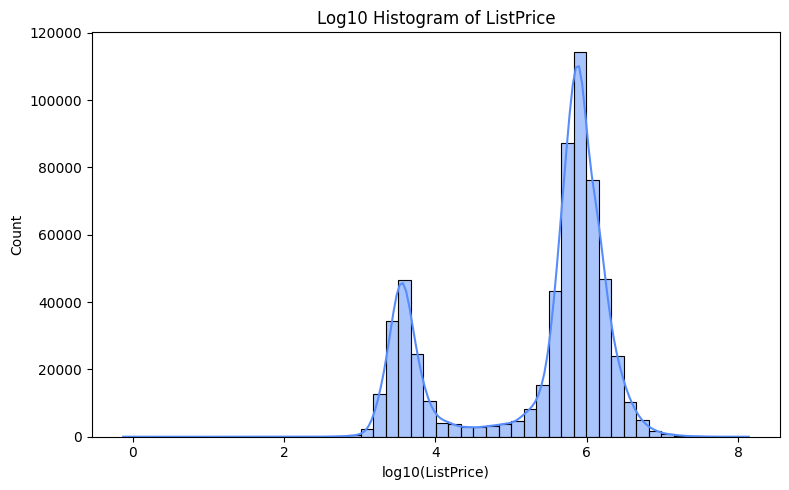

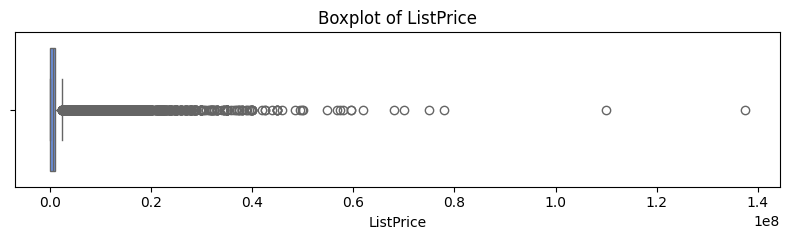

Analysis for: ListPrice

Missing values:
910

Basic summary:
count    5.908230e+05
mean     8.399733e+05
std      1.275509e+06
min      0.000000e+00
25%      6.250000e+04
50%      6.299000e+05
75%      1.050000e+06
max      1.375000e+08
Name: ListPrice, dtype: float64

Percentile summary:
0.00            0.0
0.01         1795.0
0.05         2700.0
0.10         3500.0
0.25        62500.0
0.50       629900.0
0.75      1050000.0
0.90      1780000.0
0.95      2498000.0
0.99      4999000.0
1.00    137500000.0
Name: ListPrice, dtype: float64

IQR outlier bounds:
Lower bound: -1418750.0
Upper bound: 2531250.0

Number of IQR outliers:
28229

IQR outlier percentage:
4.77 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 1795.0
99th percentile: 4999000.0

Number of extreme outliers:
11599

Lowest 10 values:
        ListPrice
354262       0.00
422279       0.00
45090        0.75
45091        0.75
45594        0.75
162644       1.00
162680       1.00
194710       1.00
33

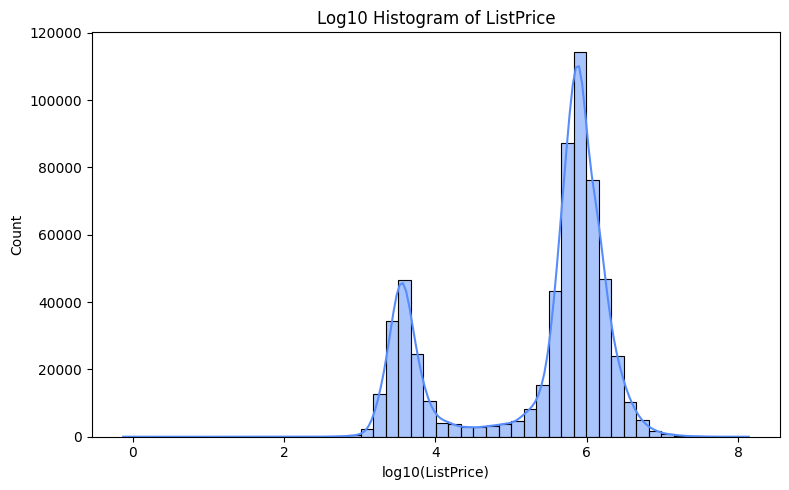

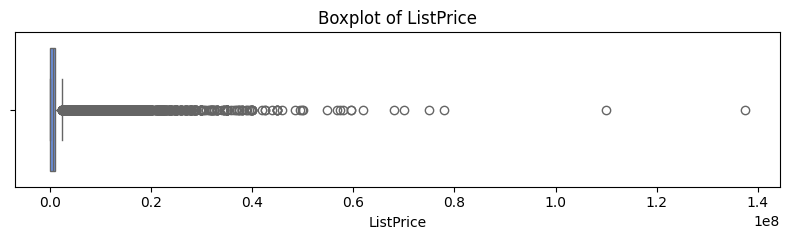

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
424310,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,"Carpet,Stone,Wood",True,NaN,155000000.0,1032371159,drew@drewfenton.com,2025-07-31,110000000.0,...,NaN,90024,NaN,200449.0,NaN,NaN,NaN,NaN,NaN,NaN
355656,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,"Stone,Wood",True,NaN,110000000.0,1112981953,stephen@sresnick.com,2025-05-08,110000000.0,...,NaN,90077,NaN,96024.0,NaN,NaN,NaN,NaN,NaN,NaN
84346,NaN,NaN,Stone,True,True,78000000.0,1046276565,kr@weahomes.com,2024-04-12,62800000.0,...,NaN,90069,NaN,63924.0,NaN,NaN,Item1,2.0,NaN,NaN
492958,SanDiego,SanDiego,NaN,False,True,75000000.0,1034539730,caren@equestrianre.com,2025-10-15,53000000.0,...,NaN,92003,NaN,61093771.2,NaN,NaN,NaN,NaN,NaN,NaN
331443,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,"Tile,Wood",True,True,69950000.0,1112274741,kr@weahomes.com,2025-04-28,60000000.0,...,NaN,90210,0.00,81620.0,NaN,NaN,NaN,NaN,NaN,NaN
396313,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,NaN,True,True,68000000.0,1108476202,ginger@gingerglass.com,2025-06-20,63100000.0,...,NaN,90210,6427.00,267415.0,NaN,NaN,NaN,NaN,NaN,NaN
353270,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,"Stone,Tile,Wood",True,NaN,62000000.0,1089803834,aaron@aaronkirman.com,2025-04-14,51750000.0,...,NaN,90210,NaN,36881.0,NaN,NaN,NaN,NaN,NaN,NaN
492667,SanDiego,SanDiego,Wood,True,True,75000000.0,1095184024,Rande@RandeTurner.com,2025-10-21,49999999.0,...,NaN,92014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568618,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,NaN,True,True,59500000.0,1155445977,NaN,2026-03-16,47000000.0,...,NaN,90210,NaN,52591.0,CRMLS,CRMLS_CL,NaN,NaN,NaN,NaN
423644,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Wood,True,True,58000000.0,1097079844,brandenwilliams@mac.com,2025-07-16,49750000.0,...,NaN,90265,NaN,44170.0,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
listprice_result_sold = analyze_numeric_field_log_hist(df_sold_cleaned, "ListPrice")
listprice_result_sold["extreme_outliers"].sort_values("ListPrice", ascending=False).head(20)

## ListPrice
listprice_result_listing = analyze_numeric_field_log_hist(df_listing_cleaned, "ListPrice")
listprice_result_listing["extreme_outliers"].sort_values("ListPrice", ascending=False).head(20)

## OriginalListPrice

Analysis for: OriginalListPrice

Missing values:
1720

Basic summary:
count    5.900130e+05
mean     9.059872e+05
std      5.742313e+06
min      0.000000e+00
25%      6.500000e+04
50%      6.399900e+05
75%      1.089000e+06
max      1.390000e+09
Name: OriginalListPrice, dtype: float64

Percentile summary:
0.00    0.000000e+00
0.01    1.800000e+03
0.05    2.750000e+03
0.10    3.500000e+03
0.25    6.500000e+04
0.50    6.399900e+05
0.75    1.089000e+06
0.90    1.799000e+06
0.95    2.549000e+06
0.99    5.298000e+06
1.00    1.390000e+09
Name: OriginalListPrice, dtype: float64

IQR outlier bounds:
Lower bound: -1471000.0
Upper bound: 2625000.0

Number of IQR outliers:
27797

IQR outlier percentage:
4.7 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 1800.0
99th percentile: 5298000.0

Number of extreme outliers:
11464

Lowest 10 values:
        OriginalListPrice
1                    0.00
82551                0.00
300967               0.00
381763               0.00

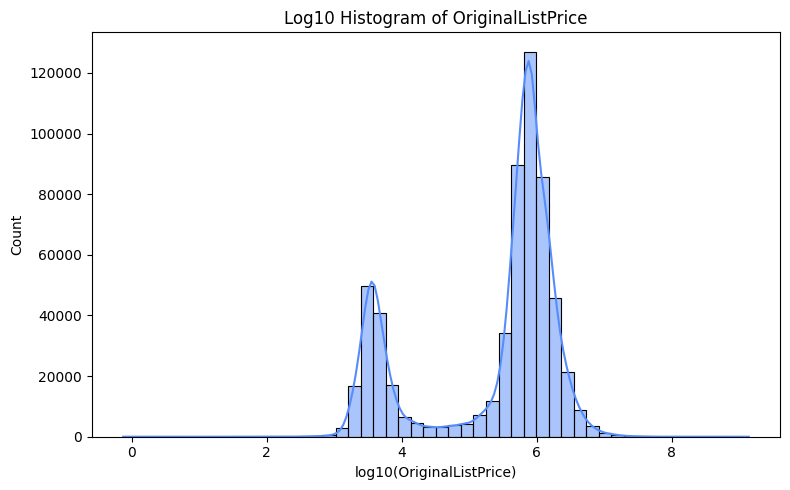

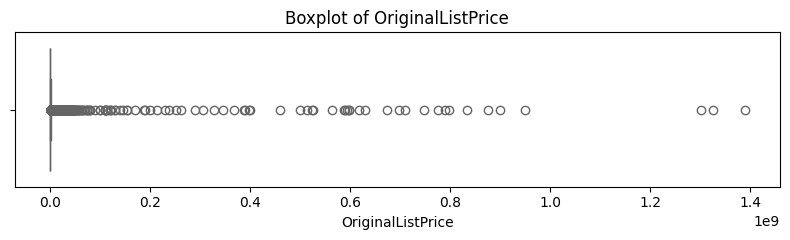

Analysis for: OriginalListPrice

Missing values:
1720

Basic summary:
count    5.900130e+05
mean     9.059872e+05
std      5.742313e+06
min      0.000000e+00
25%      6.500000e+04
50%      6.399900e+05
75%      1.089000e+06
max      1.390000e+09
Name: OriginalListPrice, dtype: float64

Percentile summary:
0.00    0.000000e+00
0.01    1.800000e+03
0.05    2.750000e+03
0.10    3.500000e+03
0.25    6.500000e+04
0.50    6.399900e+05
0.75    1.089000e+06
0.90    1.799000e+06
0.95    2.549000e+06
0.99    5.298000e+06
1.00    1.390000e+09
Name: OriginalListPrice, dtype: float64

IQR outlier bounds:
Lower bound: -1471000.0
Upper bound: 2625000.0

Number of IQR outliers:
27797

IQR outlier percentage:
4.7 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 1800.0
99th percentile: 5298000.0

Number of extreme outliers:
11464

Lowest 10 values:
        OriginalListPrice
1                    0.00
82551                0.00
300967               0.00
381763               0.00

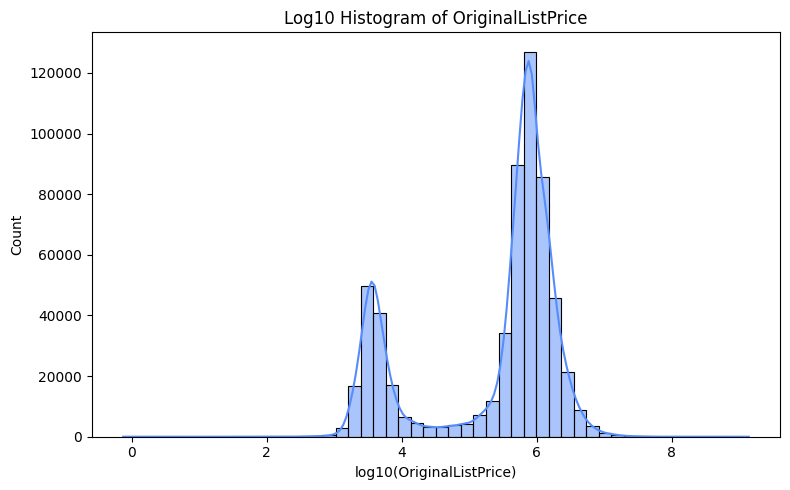

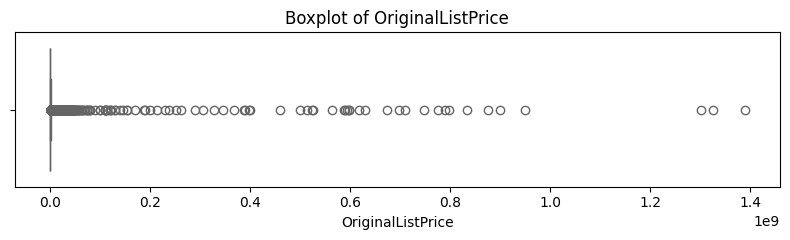

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
309095,SouthwestLosAngeles,SouthwestLosAngeles,Wood,True,False,1.390000e+09,1077473007,exoticlands2002@yahoo.com,2025-02-21,1120000.0,...,NaN,90305,NaN,6219.0,NaN,NaN,NaN,NaN,NaN,NaN
174226,PacificWest,PacificWest,Wood,True,False,1.325000e+09,1076962519,zzbaset@yahoo.com,2024-08-16,1289000.0,...,Placentia-Yorba Linda Unified,92886,117.0,5500.0,NaN,NaN,NaN,NaN,NaN,NaN
505590,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,NaN,True,NaN,1.302000e+09,1129980480,missbrentwood@yahoo.com,2025-11-05,1100000.0,...,Rowland Unified,91789,NaN,9322.0,NaN,NaN,NaN,NaN,NaN,NaN
346490,BayEast,BayEast,"Carpet,Tile,Wood",NaN,False,9.490000e+08,1106985169,perrylisac@gmail.com,2025-04-07,930000.0,...,NaN,94609,NaN,3758.0,NaN,NaN,NaN,NaN,NaN,NaN
493017,Oakland,Oakland,"Concrete,Vinyl",True,False,8.990000e+08,1147108368,matt@heafeybaum.com,2025-11-25,914000.0,...,Oakland,94611,NaN,5775.0,NaN,NaN,NaN,NaN,NaN,NaN
492980,SanDiego,SanDiego,NaN,False,False,8.750000e+08,1147175914,peter@peterheines.com,2025-11-26,875000.0,...,NaN,92064,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
412513,SanLuisObispoCoastal,SanLuisObispoCoastal,Laminate,True,False,8.345000e+08,1114483846,jeffrey.blanchard@icloud.com,2025-07-24,800000.0,...,Coast Unified,93402,0.0,5500.0,NaN,NaN,NaN,NaN,NaN,NaN
474101,BayEast,BayEast,"Laminate,Tile,Vinyl",NaN,False,7.988880e+08,1135675168,joanna.chan@compass.com,2025-10-14,818888.0,...,NaN,94541,NaN,5150.0,NaN,NaN,NaN,NaN,NaN,NaN
452571,InlandValleys,InlandValleys,Laminate,True,True,7.900000e+08,1126895789,Murillo6215@gmail.com,2025-09-17,820000.0,...,Chaffey Joint Union High,91730,0.0,9248.0,NaN,NaN,NaN,NaN,NaN,NaN
23287,NaN,NaN,NaN,False,False,7.759000e+08,1058366378,analidiamenjivar@yahoo.com,2024-02-29,775900.0,...,Los Angeles Unified,91402,0.0,7442.0,NaN,NaN,Item1,2.0,NaN,NaN


In [23]:
original_listprice_result_sold = analyze_numeric_field_log_hist(df_sold_cleaned, "OriginalListPrice")
original_listprice_result_sold["extreme_outliers"].sort_values("OriginalListPrice", ascending=False).head(20)

original_listprice_result_listing = analyze_numeric_field_log_hist(df_listing_cleaned, "OriginalListPrice")
original_listprice_result_listing["extreme_outliers"].sort_values("OriginalListPrice", ascending=False).head(20)

## LivingArea

Analysis for: LivingArea

Missing values:
41782

Basic summary:
count    5.499510e+05
mean     3.495372e+03
std      1.226086e+06
min      0.000000e+00
25%      1.183000e+03
50%      1.579000e+03
75%      2.150000e+03
max      9.090909e+08
Name: LivingArea, dtype: float64

Percentile summary:
0.00            0.0
0.01          480.0
0.05          734.0
0.10          896.0
0.25         1183.0
0.50         1579.0
0.75         2150.0
0.90         2921.0
0.95         3537.0
0.99         5464.5
1.00    909090909.0
Name: LivingArea, dtype: float64

IQR outlier bounds:
Lower bound: -267.5
Upper bound: 3600.5

Number of IQR outliers:
25746

IQR outlier percentage:
4.35 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 480.0
99th percentile: 5464.5

Number of extreme outliers:
10820

Lowest 10 values:
       LivingArea
411           0.0
803           0.0
3264          0.0
3836          0.0
5887          0.0
7764          0.0
9667          0.0
12671         0.0
13625   

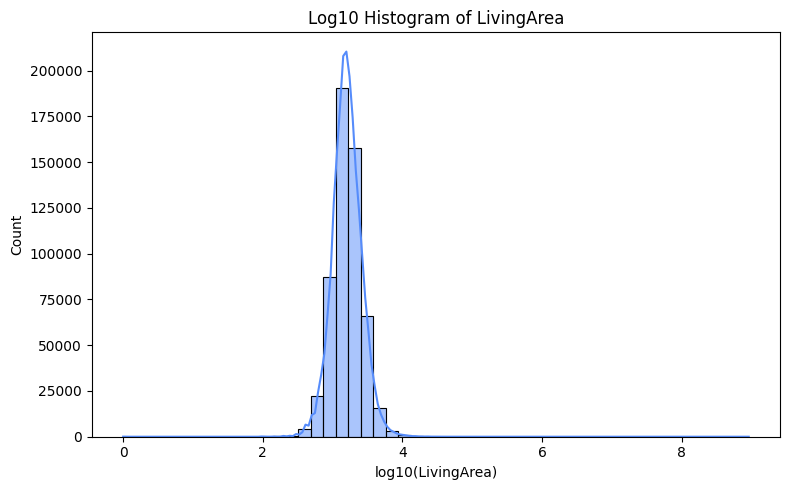

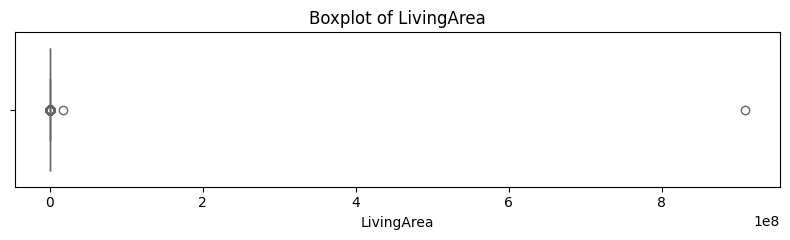

Analysis for: LivingArea

Missing values:
41782

Basic summary:
count    5.499510e+05
mean     3.495372e+03
std      1.226086e+06
min      0.000000e+00
25%      1.183000e+03
50%      1.579000e+03
75%      2.150000e+03
max      9.090909e+08
Name: LivingArea, dtype: float64

Percentile summary:
0.00            0.0
0.01          480.0
0.05          734.0
0.10          896.0
0.25         1183.0
0.50         1579.0
0.75         2150.0
0.90         2921.0
0.95         3537.0
0.99         5464.5
1.00    909090909.0
Name: LivingArea, dtype: float64

IQR outlier bounds:
Lower bound: -267.5
Upper bound: 3600.5

Number of IQR outliers:
25746

IQR outlier percentage:
4.35 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 480.0
99th percentile: 5464.5

Number of extreme outliers:
10820

Lowest 10 values:
       LivingArea
411           0.0
803           0.0
3264          0.0
3836          0.0
5887          0.0
7764          0.0
9667          0.0
12671         0.0
13625   

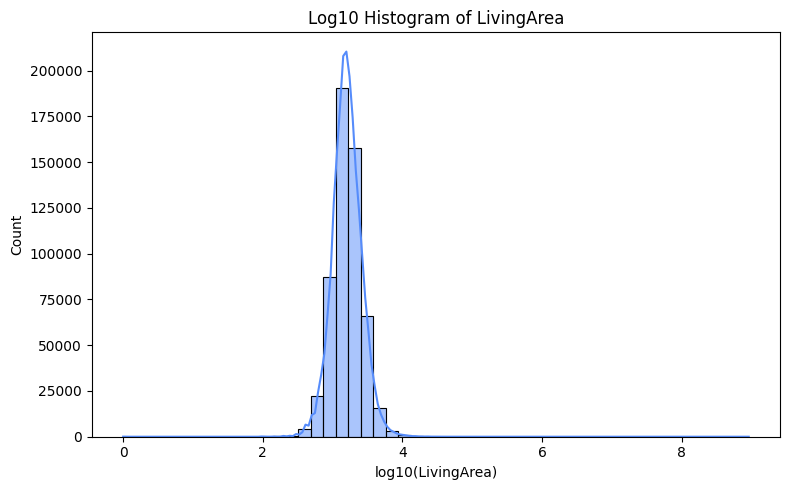

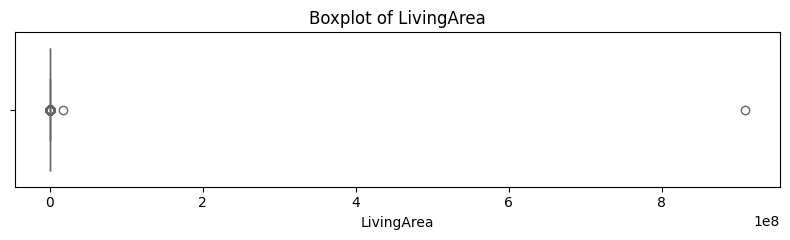

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
185083,ContraCosta,ContraCosta,"Carpet,Tile",NaN,False,2195.0,1067203748,bartelspm@aol.com,2024-08-01,1950.0,...,NaN,94804,NaN,8625.0,NaN,NaN,NaN,NaN,NaN,NaN
340889,SanDiego,SanDiego,NaN,True,False,616000.0,1108264257,karen.smith@tripointehomes.com,2025-04-29,631099.0,...,NaN,92154,382.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
253428,Conejo,Conejo,NaN,False,False,195000.0,1097107785,andreajacobs888@gmail.com,2024-12-26,186500.0,...,NaN,91304,NaN,357351.0,NaN,NaN,NaN,NaN,NaN,NaN
374925,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Laminate,True,NaN,3800.0,1102991297,Jessica@PropertiesByJessica.com,2025-05-21,3600.0,...,NaN,90024,NaN,68434.0,NaN,NaN,NaN,NaN,NaN,NaN
349604,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Laminate,True,NaN,3800.0,1102991470,Jessica@PropertiesByJessica.com,2025-04-15,3600.0,...,NaN,90024,NaN,68434.0,NaN,NaN,NaN,NaN,NaN,NaN
215680,Mlslistings,Mlslistings,Laminate,False,NaN,2300.0,1086443517,sharlynemurphy@gmail.com,2024-10-15,2300.0,...,Other,94066,NaN,540.0,NaN,NaN,NaN,NaN,NaN,NaN
156680,BeverlyHillsGreaterLA,BeverlyHillsGreaterLA,NaN,True,NaN,50000000.0,1073132609,tdipri@gmail.com,2024-07-10,16700000.0,...,NaN,93105,NaN,495277.0,NaN,NaN,NaN,NaN,0.0,0.0
549605,Oakland,ContraCosta,"Laminate,Tile",NaN,False,750.0,1152983074,NaN,2026-02-21,750.0,...,NaN,94606,NaN,129373.0,CRMLS,CRMLS_CCBE,NaN,NaN,NaN,NaN
458878,ContraCosta,ContraCosta,"Laminate,Tile",NaN,False,4200.0,1119658807,fmartince@hotmail.com,2025-09-26,3800.0,...,NaN,94606,NaN,7000.0,NaN,NaN,NaN,NaN,NaN,NaN
372792,SouthwestRiversideCounty,SouthwestRiversideCounty,NaN,False,False,441150.0,1107279308,sold@myattrealestate.com,2025-05-09,406850.0,...,Mountain View,91762,360.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
livingarea_result_sold = analyze_numeric_field_log_hist(df_sold_cleaned, "LivingArea")
livingarea_result_sold["extreme_outliers"].sort_values("LivingArea", ascending=False).head(20)

livingarea_result_listing = analyze_numeric_field_log_hist(df_listing_cleaned, "LivingArea")
livingarea_result_listing["extreme_outliers"].sort_values("LivingArea", ascending=False).head(20)

## LotSizeAcres

Analysis for: LotSizeAcres

Missing values:
56032

Basic summary:
count    5.357010e+05
mean     7.629230e+02
std      5.060694e+05
min      0.000000e+00
25%      1.194000e-01
50%      1.677000e-01
75%      2.985000e-01
max      3.702600e+08
Name: LotSizeAcres, dtype: float64

Percentile summary:
0.00    0.000000e+00
0.01    0.000000e+00
0.05    2.750000e-02
0.10    5.740000e-02
0.25    1.194000e-01
0.50    1.677000e-01
0.75    2.985000e-01
0.90    1.270000e+00
0.95    3.581800e+00
0.99    1.585000e+01
1.00    3.702600e+08
Name: LotSizeAcres, dtype: float64

IQR outlier bounds:
Lower bound: -0.14924999999999994
Upper bound: 0.5671499999999999

Number of IQR outliers:
85053

IQR outlier percentage:
14.37 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 0.0
99th percentile: 15.85

Number of extreme outliers:
5353

Lowest 10 values:
     LotSizeAcres
34            0.0
141           0.0
142           0.0
144           0.0
200           0.0
205           0.0
206 

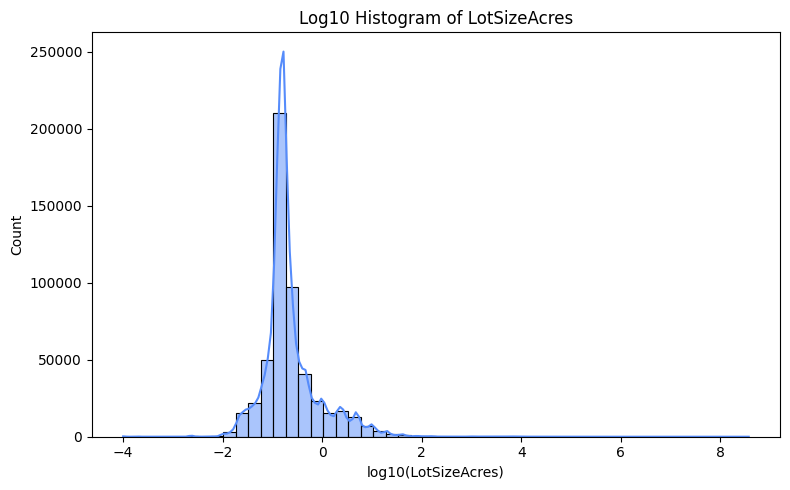

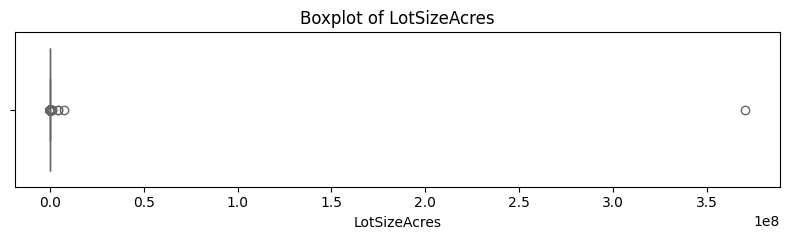

Analysis for: LotSizeAcres

Missing values:
56032

Basic summary:
count    5.357010e+05
mean     7.629230e+02
std      5.060694e+05
min      0.000000e+00
25%      1.194000e-01
50%      1.677000e-01
75%      2.985000e-01
max      3.702600e+08
Name: LotSizeAcres, dtype: float64

Percentile summary:
0.00    0.000000e+00
0.01    0.000000e+00
0.05    2.750000e-02
0.10    5.740000e-02
0.25    1.194000e-01
0.50    1.677000e-01
0.75    2.985000e-01
0.90    1.270000e+00
0.95    3.581800e+00
0.99    1.585000e+01
1.00    3.702600e+08
Name: LotSizeAcres, dtype: float64

IQR outlier bounds:
Lower bound: -0.14924999999999994
Upper bound: 0.5671499999999999

Number of IQR outliers:
85053

IQR outlier percentage:
14.37 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 0.0
99th percentile: 15.85

Number of extreme outliers:
5353

Lowest 10 values:
     LotSizeAcres
34            0.0
141           0.0
142           0.0
144           0.0
200           0.0
205           0.0
206 

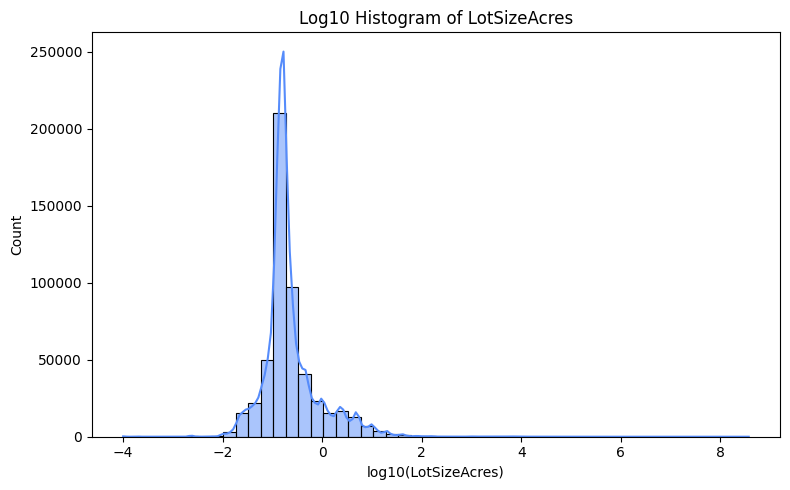

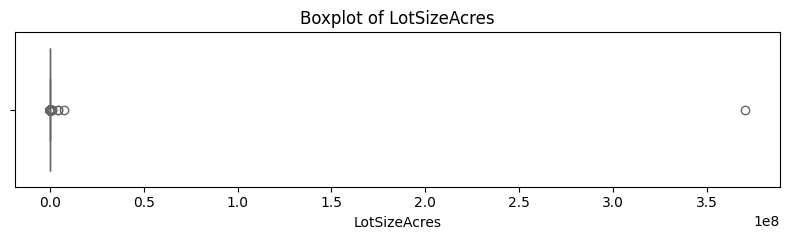

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
18629,NaN,NaN,NaN,False,False,1995.0,1061171713,gaelyn@bullockrussell.com,2024-02-28,2495.0,...,Capistrano Unified,92679,NaN,NaN,NaN,NaN,Item1,2.5,NaN,NaN
84981,NaN,NaN,"Carpet,Stone",True,True,3950000.0,1044879844,juliereeskerealtor@yahoo.com,2024-04-12,3600000.0,...,NaN,92253,355.00,NaN,NaN,NaN,Item1,2.5,NaN,NaN
367134,NorthSanDiegoCounty,NorthSanDiegoCounty,NaN,True,False,470000.0,1109200812,jancarver4650@gmail.com,2025-05-29,460000.0,...,Bonsall Unified,92028,354.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
442487,NorthSanDiegoCounty,NorthSanDiegoCounty,NaN,True,False,375500.0,1112991886,jancarver4650@gmail.com,2025-08-01,320000.0,...,Bonsall Unified,92028,354.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
200913,NorthSanDiegoCounty,NorthSanDiegoCounty,NaN,True,False,285000.0,1077450021,cathysteiger@outlook.com,2024-09-16,269000.0,...,ABC Unified,92056,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11657,Oakland,Oakland,"Carpet,Tile,Wood",NaN,False,2600.0,1046597270,jacklondonrealty@gmail.com,2024-01-19,2600.0,...,NaN,94607,NaN,999999.0,CRMLS,CRMLS_BMLS,NaN,NaN,NaN,NaN
436360,PacificSouthwest,PacificSouthwest,NaN,False,False,265000.0,1117762820,shoppingsdhouses@gmail.com,2025-08-14,265000.0,...,Other,92114,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
428333,PalosVerdesPeninsula,PalosVerdesPeninsula,"Carpet,Laminate",True,True,4000.0,1119724277,Antonia@AntoniaLavender.com,2025-08-06,4000.0,...,Palos Verdes Peninsula Unified,90275,995.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
228453,TheInlandGateway,TheInlandGateway,Wood,True,False,642000.0,1076887117,Excellencemasters22@gmail.com,2024-10-24,400000.0,...,Los Angeles Unified,90042,807.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
226525,NorthSanDiegoCounty,NorthSanDiegoCounty,NaN,True,False,539000.0,1077692837,ivansellsrealestate@gmail.com,2024-10-08,544000.0,...,Escondido Union,92028,450.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
lotsize_result_sold = analyze_numeric_field_log_hist(df_sold_cleaned, "LotSizeAcres")
lotsize_result_sold["extreme_outliers"].sort_values("LotSizeAcres", ascending=False).head(20)

## LotSizeAcres
lotsize_result_listing = analyze_numeric_field_log_hist(df_listing_cleaned, "LotSizeAcres")
lotsize_result_listing["extreme_outliers"].sort_values("LotSizeAcres", ascending=False).head(20)

## BedroomsTotal

Analysis for: BedroomsTotal

Percentile summary:
0.00      0.0
0.01      1.0
0.05      1.0
0.10      2.0
0.25      2.0
0.50      3.0
0.75      4.0
0.90      4.0
0.95      5.0
0.99      6.0
1.00    123.0
Name: BedroomsTotal, dtype: float64

IQR outlier bounds:
Lower bound: -1.0
Upper bound: 7.0

Number of outliers:
2069

Outlier percentage:
0.35 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 1.0
99th percentile: 6.0

Number of extreme outliers:
8136

Lowest 10 values:
     BedroomsTotal
28             0.0
41             0.0
104            0.0
107            0.0
141            0.0
173            0.0
206            0.0
224            0.0
235            0.0
237            0.0

Highest 10 values:
        BedroomsTotal
524766          123.0
135826          112.0
329290          100.0
456629           99.0
567128           99.0
354869           95.0
544314           81.0
422868           78.0
490334           77.0
219766           76.0


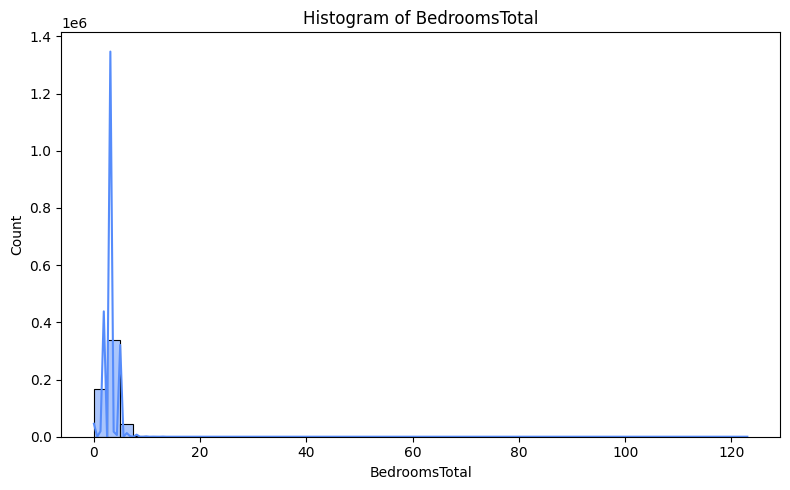

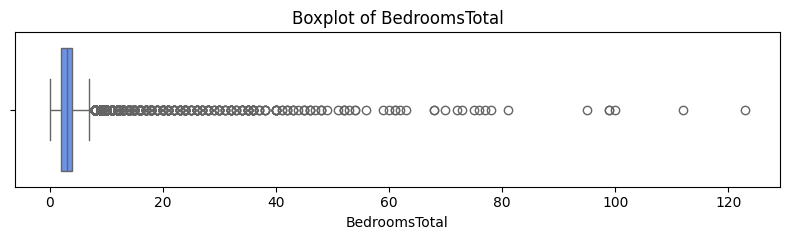

Analysis for: BedroomsTotal

Percentile summary:
0.00      0.0
0.01      1.0
0.05      1.0
0.10      2.0
0.25      2.0
0.50      3.0
0.75      4.0
0.90      4.0
0.95      5.0
0.99      6.0
1.00    123.0
Name: BedroomsTotal, dtype: float64

IQR outlier bounds:
Lower bound: -1.0
Upper bound: 7.0

Number of outliers:
2069

Outlier percentage:
0.35 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 1.0
99th percentile: 6.0

Number of extreme outliers:
8136

Lowest 10 values:
     BedroomsTotal
28             0.0
41             0.0
104            0.0
107            0.0
141            0.0
173            0.0
206            0.0
224            0.0
235            0.0
237            0.0

Highest 10 values:
        BedroomsTotal
524766          123.0
135826          112.0
329290          100.0
456629           99.0
567128           99.0
354869           95.0
544314           81.0
422868           78.0
490334           77.0
219766           76.0


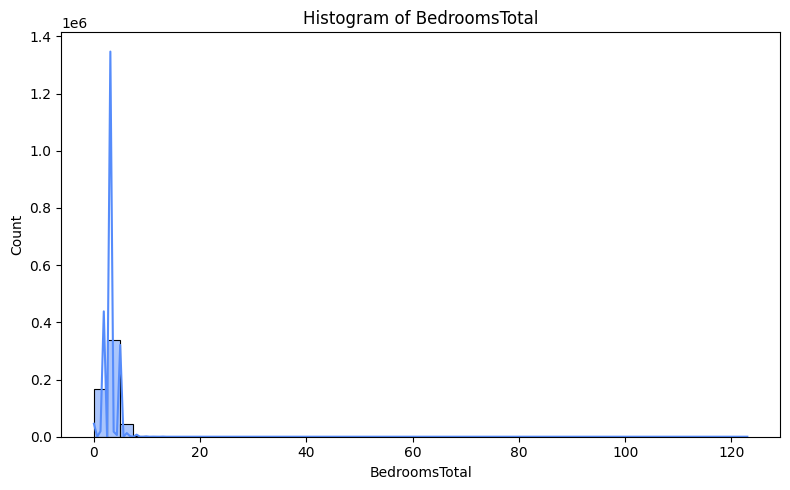

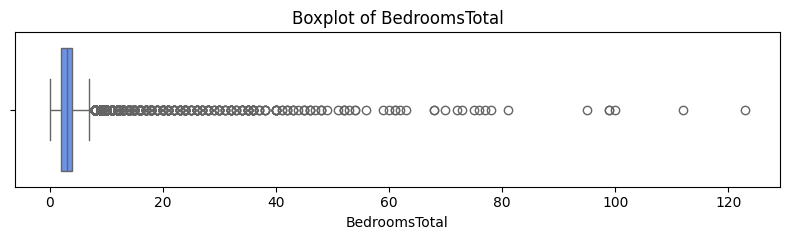

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
524766,OutOfAreaBoard,OutOfAreaBoard,NaN,NaN,NaN,19500000.0,1137027082,Josh@cohengroupla.com,2025-12-24,19500000.0,...,NaN,90723,NaN,48351.0,NaN,NaN,NaN,NaN,NaN,NaN
135826,BeverlyHillsGreaterLA,BeverlyHillsGreaterLA,NaN,NaN,NaN,18495000.0,1046808289,john.swartz@compass.com,2024-06-13,16300000.0,...,NaN,91335,NaN,60791.0,NaN,NaN,NaN,NaN,0.0,0.0
329290,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,NaN,NaN,NaN,17395000.0,1089844225,Chase@RemaxOneCommercial.com,2025-03-05,15700000.0,...,NaN,91325,NaN,36490.0,NaN,NaN,NaN,NaN,NaN,NaN
456629,OutOfAreaBoard,OutOfAreaBoard,NaN,NaN,NaN,26000000.0,1120081314,nick@maywoodpropertygroup.com,2025-09-15,26350000.0,...,NaN,91792,NaN,227714.0,NaN,NaN,NaN,NaN,NaN,NaN
567128,Claw,Claw,NaN,False,NaN,8500000.0,1119032467,NaN,2026-02-17,7600000.0,...,NaN,90027,NaN,30152.0,CRMLS,CRMLS_CL,NaN,NaN,NaN,NaN
354869,OutOfAreaBoard,OutOfAreaBoard,NaN,NaN,NaN,20040000.0,1114338984,john@brcadvisors.com,2025-05-20,20040000.0,...,NaN,90275,NaN,81220.0,NaN,NaN,NaN,NaN,NaN,NaN
544314,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Laminate,NaN,False,14490000.0,1138525096,krstepp@steppcommercial.com,2026-01-12,13550000.0,...,NaN,90249,NaN,53757.0,NaN,NaN,NaN,NaN,NaN,NaN
422868,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,NaN,NaN,NaN,9500000.0,1104230658,rob@taksainvestment.com,2025-07-25,8450000.0,...,NaN,91325,NaN,48613.0,NaN,NaN,NaN,NaN,NaN,NaN
490334,Claw,Claw,NaN,NaN,NaN,13750000.0,1114443823,brett.sanson@marcusmillichap.com,2025-10-15,13145000.0,...,NaN,91601,NaN,32209.0,NaN,NaN,NaN,NaN,NaN,NaN
219766,Claw,Claw,Laminate,True,False,5495.0,1081917645,shahin@wisemanresidential.com,2024-10-11,5495.0,...,NaN,90049,NaN,15755.0,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
bedrooms_result_sold = analyze_numeric_field(df_sold_cleaned, "BedroomsTotal")
bedrooms_result_sold["extreme_outliers"].sort_values("BedroomsTotal", ascending=False).head(20)

bedrooms_result_listing = analyze_numeric_field(df_listing_cleaned, "BedroomsTotal")
bedrooms_result_listing["extreme_outliers"].sort_values("BedroomsTotal", ascending=False).head(20)


## BathoroomsTotalInteger

Analysis for: BathroomsTotalInteger

Percentile summary:
0.00      0.0
0.01      0.0
0.05      1.0
0.10      1.0
0.25      2.0
0.50      2.0
0.75      3.0
0.90      4.0
0.95      4.0
0.99      6.0
1.00    175.0
Name: BathroomsTotalInteger, dtype: float64

IQR outlier bounds:
Lower bound: 0.5
Upper bound: 4.5

Number of outliers:
37325

Outlier percentage:
6.31 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 0.0
99th percentile: 6.0

Number of extreme outliers:
4599

Lowest 10 values:
    BathroomsTotalInteger
14                    0.0
15                    0.0
22                    0.0
31                    0.0
36                    0.0
38                    0.0
46                    0.0
51                    0.0
69                    0.0
75                    0.0

Highest 10 values:
        BathroomsTotalInteger
32345                   175.0
252707                  153.0
524766                  123.0
135826                  106.0
329290                  10

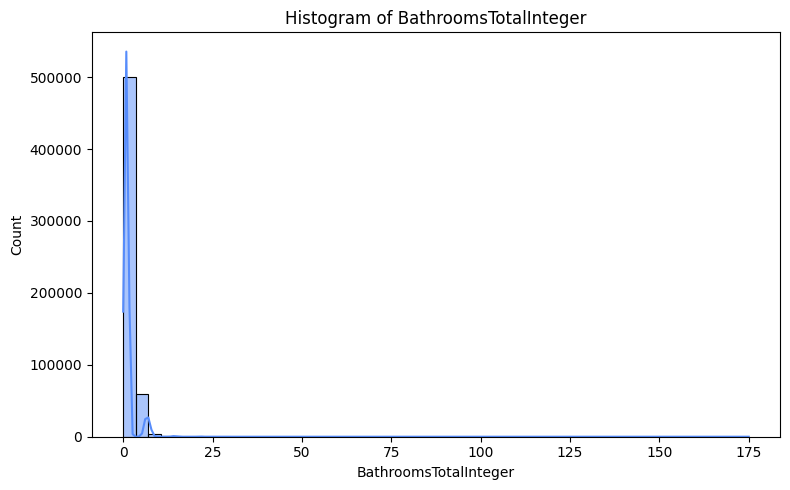

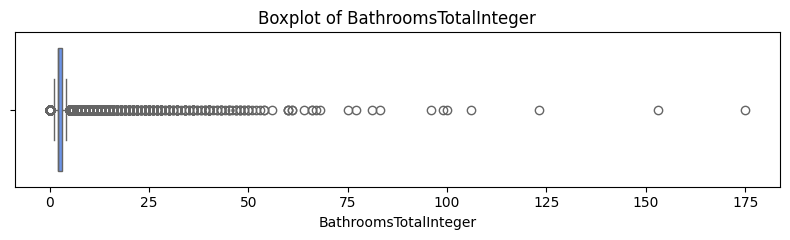

Analysis for: BathroomsTotalInteger

Percentile summary:
0.00      0.0
0.01      0.0
0.05      1.0
0.10      1.0
0.25      2.0
0.50      2.0
0.75      3.0
0.90      4.0
0.95      4.0
0.99      6.0
1.00    175.0
Name: BathroomsTotalInteger, dtype: float64

IQR outlier bounds:
Lower bound: 0.5
Upper bound: 4.5

Number of outliers:
37325

Outlier percentage:
6.31 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 0.0
99th percentile: 6.0

Number of extreme outliers:
4599

Lowest 10 values:
    BathroomsTotalInteger
14                    0.0
15                    0.0
22                    0.0
31                    0.0
36                    0.0
38                    0.0
46                    0.0
51                    0.0
69                    0.0
75                    0.0

Highest 10 values:
        BathroomsTotalInteger
32345                   175.0
252707                  153.0
524766                  123.0
135826                  106.0
329290                  10

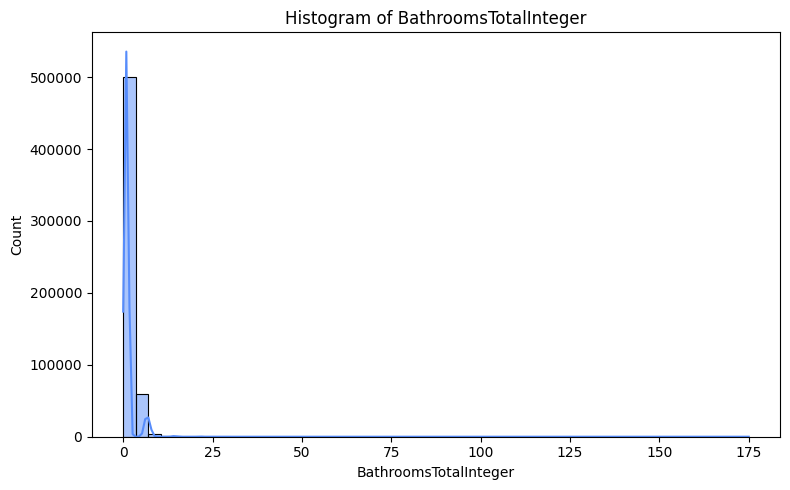

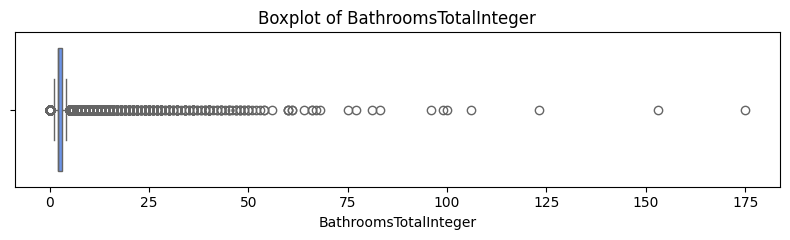

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
32345,NaN,NaN,NaN,False,False,369000.0,1048518293,aracelisellshomes@gmail.com,2024-02-02,368500.0,...,NaN,92586,33.0,NaN,NaN,NaN,Item1,2.5,NaN,NaN
252707,PasadenaFoothills,PasadenaFoothills,Wood,False,False,821000.0,1098842075,brian@larsenpropertiesla.com,2024-12-19,821000.0,...,NaN,90605,NaN,5998.0,NaN,NaN,NaN,NaN,NaN,NaN
524766,OutOfAreaBoard,OutOfAreaBoard,NaN,NaN,NaN,19500000.0,1137027082,Josh@cohengroupla.com,2025-12-24,19500000.0,...,NaN,90723,NaN,48351.0,NaN,NaN,NaN,NaN,NaN,NaN
135826,BeverlyHillsGreaterLA,BeverlyHillsGreaterLA,NaN,NaN,NaN,18495000.0,1046808289,john.swartz@compass.com,2024-06-13,16300000.0,...,NaN,91335,NaN,60791.0,NaN,NaN,NaN,NaN,0.0,0.0
329290,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,NaN,NaN,NaN,17395000.0,1089844225,Chase@RemaxOneCommercial.com,2025-03-05,15700000.0,...,NaN,91325,NaN,36490.0,NaN,NaN,NaN,NaN,NaN,NaN
456629,OutOfAreaBoard,OutOfAreaBoard,NaN,NaN,NaN,26000000.0,1120081314,nick@maywoodpropertygroup.com,2025-09-15,26350000.0,...,NaN,91792,NaN,227714.0,NaN,NaN,NaN,NaN,NaN,NaN
354869,OutOfAreaBoard,OutOfAreaBoard,NaN,NaN,NaN,20040000.0,1114338984,john@brcadvisors.com,2025-05-20,20040000.0,...,NaN,90275,NaN,81220.0,NaN,NaN,NaN,NaN,NaN,NaN
544314,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Laminate,NaN,False,14490000.0,1138525096,krstepp@steppcommercial.com,2026-01-12,13550000.0,...,NaN,90249,NaN,53757.0,NaN,NaN,NaN,NaN,NaN,NaN
396831,Claw,Claw,NaN,NaN,NaN,9950000.0,1108257508,Matt.Ziegler@marcusmillichap.com,2025-06-24,9100000.0,...,NaN,91606,NaN,45450.0,NaN,NaN,NaN,NaN,NaN,NaN
490334,Claw,Claw,NaN,NaN,NaN,13750000.0,1114443823,brett.sanson@marcusmillichap.com,2025-10-15,13145000.0,...,NaN,91601,NaN,32209.0,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
bathrooms_result_sold = analyze_numeric_field(df_sold_cleaned, "BathroomsTotalInteger")
bathrooms_result_sold["extreme_outliers"].sort_values("BathroomsTotalInteger", ascending=False).head(20)


bathrooms_result_listing = analyze_numeric_field(df_listing_cleaned, "BathroomsTotalInteger")
bathrooms_result_listing["extreme_outliers"].sort_values("BathroomsTotalInteger", ascending=False).head(20)


## DaysOnMarket

Analysis for: DaysOnMarket

Missing values:
0

Basic summary:
count    591733.000000
mean         43.292994
std          69.841987
min        -288.000000
25%           9.000000
50%          22.000000
75%          54.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64

Percentile summary:
0.00     -288.0
0.01        0.0
0.05        2.0
0.10        4.0
0.25        9.0
0.50       22.0
0.75       54.0
0.90      103.0
0.95      147.0
0.99      290.0
1.00    12430.0
Name: DaysOnMarket, dtype: float64

IQR outlier bounds:
Lower bound: -58.5
Upper bound: 121.5

Number of IQR outliers:
43862

IQR outlier percentage:
7.41 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 0.0
99th percentile: 290.0

Number of extreme outliers:
5977

Lowest 10 values:
        DaysOnMarket
309898          -288
512020          -265
131629           -84
512005           -65
422445           -63
38197            -58
57766            -57
208650           -56
38171            -48


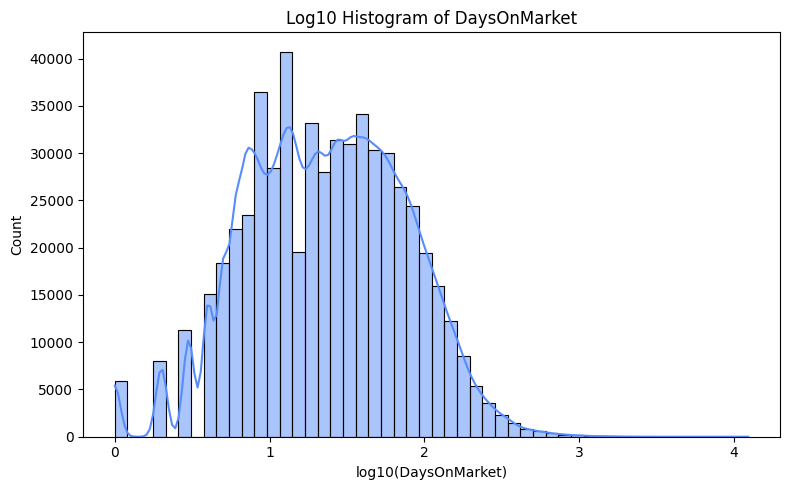

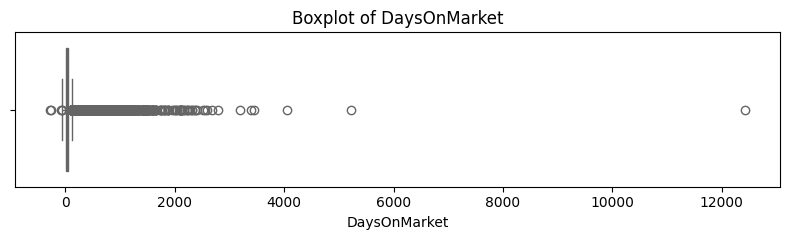

Analysis for: DaysOnMarket

Missing values:
0

Basic summary:
count    591733.000000
mean         43.292994
std          69.841987
min        -288.000000
25%           9.000000
50%          22.000000
75%          54.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64

Percentile summary:
0.00     -288.0
0.01        0.0
0.05        2.0
0.10        4.0
0.25        9.0
0.50       22.0
0.75       54.0
0.90      103.0
0.95      147.0
0.99      290.0
1.00    12430.0
Name: DaysOnMarket, dtype: float64

IQR outlier bounds:
Lower bound: -58.5
Upper bound: 121.5

Number of IQR outliers:
43862

IQR outlier percentage:
7.41 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 0.0
99th percentile: 290.0

Number of extreme outliers:
5977

Lowest 10 values:
        DaysOnMarket
309898          -288
512020          -265
131629           -84
512005           -65
422445           -63
38197            -58
57766            -57
208650           -56
38171            -48


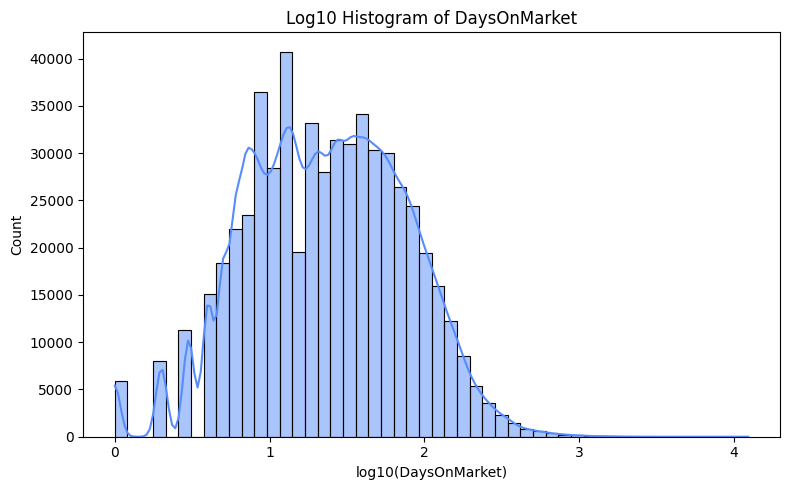

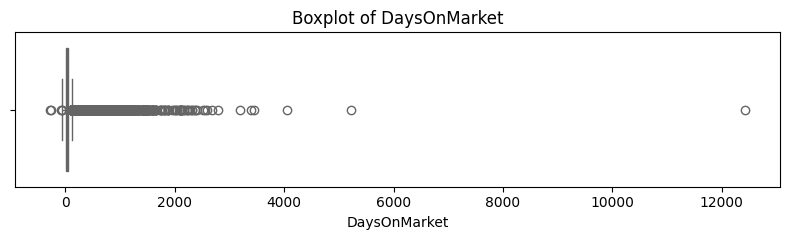

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
160019,SouthwestLosAngeles,SouthwestLosAngeles,Wood,False,False,699000.0,1064432110,anna@wallstreetsellsla.com,2024-07-24,650000.00,...,NaN,90044,NaN,2707.00,NaN,NaN,NaN,NaN,0.0,0.0
61195,NaN,NaN,NaN,NaN,NaN,2.0,446206103,mark@andersoncommercialre.com,2024-04-03,2.95,...,NaN,93405,NaN,0.00,NaN,NaN,Item1,2.5,NaN,NaN
26,EastValley,EastValley,NaN,True,NaN,20000.0,421685986,BEN@YVRE.COM,2024-01-26,7000.00,...,NaN,93535,0.0,229143.00,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
17992,NaN,NaN,NaN,True,NaN,31000.0,446939902,dmasonrealtor@gmail.com,2024-02-28,21000.00,...,NaN,96137,0.0,14810.00,NaN,NaN,Item1,5.0,NaN,NaN
272494,HighDesert,HighDesert,NaN,True,NaN,100000.0,446933645,billquimby.re@gmail.com,2025-01-08,100000.00,...,NaN,92307,NaN,217800.00,NaN,NaN,NaN,NaN,0.0,0.0
112320,SierraNorthValley,SierraNorthValley,NaN,True,NaN,396000.0,446554185,Billymac058@gmail.com,2024-06-06,376000.00,...,NaN,95963,0.0,131987.00,NaN,NaN,NaN,NaN,1.0,1.0
291236,SanLuisObispoCoastal,SanLuisObispoCoastal,NaN,True,NaN,825000.0,446018934,Steve@BearValleyRE.com,2025-02-05,699000.00,...,NaN,93402,0.0,90169.00,NaN,NaN,NaN,NaN,NaN,NaN
252261,Southland,Southland,NaN,True,NaN,20990.0,421653392,mr.khatibi@yahoo.com,2024-12-24,22000.00,...,NaN,93551,0.0,19722.00,NaN,NaN,NaN,NaN,NaN,NaN
291240,Southland,Southland,NaN,True,NaN,355000.0,421653552,mr.khatibi@yahoo.com,2025-02-26,196000.00,...,NaN,93550,0.0,24897.00,NaN,NaN,NaN,NaN,NaN,NaN
136653,Southland,Southland,NaN,True,NaN,25990.0,421652543,mr.khatibi@yahoo.com,2024-07-05,20990.00,...,NaN,93551,0.0,19886.00,NaN,NaN,NaN,NaN,0.0,0.0


In [38]:
daysonmarket_result_sold = analyze_numeric_field_log_hist(df_sold_cleaned, "DaysOnMarket")
daysonmarket_result_sold["extreme_outliers"].sort_values("DaysOnMarket", ascending=False).head(20)

daysonmarket_result_listing = analyze_numeric_field_log_hist(df_listing_cleaned, "DaysOnMarket")
daysonmarket_result_listing["extreme_outliers"].sort_values("DaysOnMarket", ascending=False).head(20)

## YearBuilt

Analysis for: YearBuilt

Missing values:
24950

Basic summary:
count    566783.000000
mean       1978.103503
std          27.091860
min        1776.000000
25%        1960.000000
50%        1979.000000
75%        1999.000000
max        2026.000000
Name: YearBuilt, dtype: float64

Percentile summary:
0.00    1776.0
0.01    1911.0
0.05    1927.0
0.10    1945.0
0.25    1960.0
0.50    1979.0
0.75    1999.0
0.90    2017.0
0.95    2022.0
0.99    2025.0
1.00    2026.0
Name: YearBuilt, dtype: float64

IQR outlier bounds:
Lower bound: 1901.5
Upper bound: 2057.5

Number of IQR outliers:
1525

IQR outlier percentage:
0.26 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 1911.0
99th percentile: 2025.0

Number of extreme outliers:
5748

Lowest 10 values:
        YearBuilt
32728      1776.0
42875      1776.0
42877      1776.0
88584      1776.0
131444     1776.0
298804     1776.0
457010     1776.0
1012       1778.0
343922     1800.0
425988     1800.0

Highest 10 values:
   

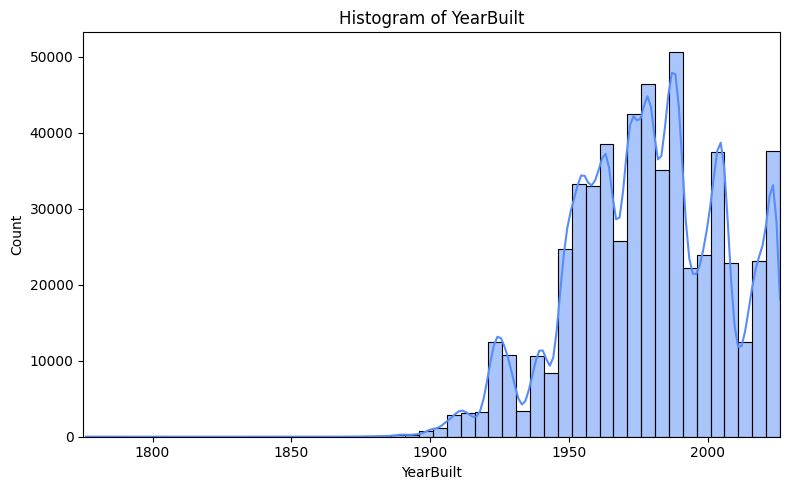

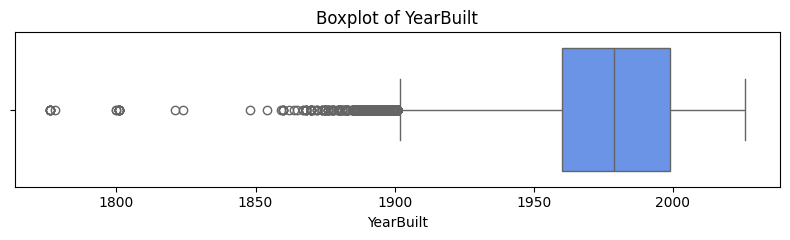

Analysis for: YearBuilt

Missing values:
24950

Basic summary:
count    566783.000000
mean       1978.103503
std          27.091860
min        1776.000000
25%        1960.000000
50%        1979.000000
75%        1999.000000
max        2026.000000
Name: YearBuilt, dtype: float64

Percentile summary:
0.00    1776.0
0.01    1911.0
0.05    1927.0
0.10    1945.0
0.25    1960.0
0.50    1979.0
0.75    1999.0
0.90    2017.0
0.95    2022.0
0.99    2025.0
1.00    2026.0
Name: YearBuilt, dtype: float64

IQR outlier bounds:
Lower bound: 1901.5
Upper bound: 2057.5

Number of IQR outliers:
1525

IQR outlier percentage:
0.26 %

Extreme outlier bounds based on 1st and 99th percentiles:
1st percentile: 1911.0
99th percentile: 2025.0

Number of extreme outliers:
5748

Lowest 10 values:
        YearBuilt
32728      1776.0
42875      1776.0
42877      1776.0
88584      1776.0
131444     1776.0
298804     1776.0
457010     1776.0
1012       1778.0
343922     1800.0
425988     1800.0

Highest 10 values:
   

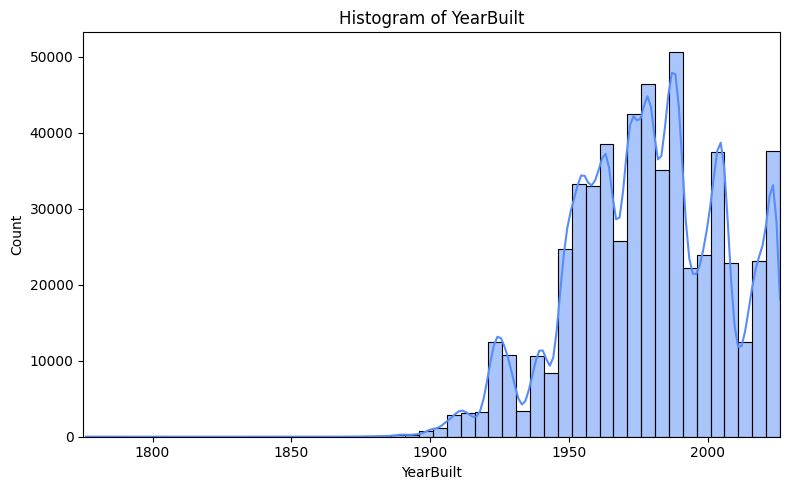

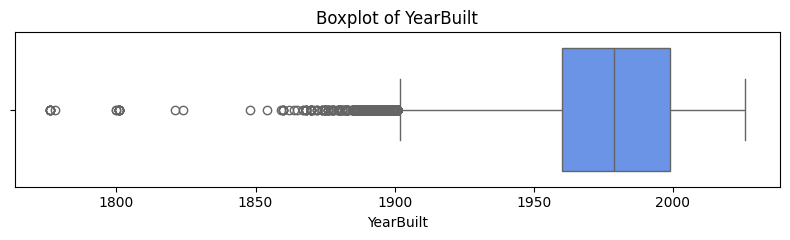

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
88584,CitrusValley,CitrusValley,NaN,False,False,1800.0,1073203055,offers@calamericanhomes.com,2024-05-30,1900.0,...,Palm Springs Unified,92264,0.0,1.001900e+04,NaN,NaN,NaN,NaN,0.0,0.0
42875,NaN,NaN,Carpet,True,True,825000.0,1061488481,steve@cvdprop.com,2024-03-29,800000.0,...,NaN,92234,0.0,1.393900e+04,NaN,NaN,Item1,2.50,NaN,NaN
42877,NaN,NaN,NaN,False,True,825000.0,1061488477,steve@cvdprop.com,2024-03-29,800000.0,...,NaN,92234,0.0,1.437500e+04,NaN,NaN,Item1,2.50,NaN,NaN
457010,Downey,Downey,Vinyl,True,False,600000.0,1120009822,diego.delgadillo@soldbymmg.com,2025-09-09,600000.0,...,Riverside Unified,92508,0.0,1.846940e+05,NaN,NaN,NaN,NaN,NaN,NaN
298804,SouthwestRiversideCounty,SouthwestRiversideCounty,NaN,NaN,NaN,550000.0,1102517049,Heron@heronsellshomes.com,2025-02-28,550000.0,...,NaN,92567,NaN,1.089000e+04,NaN,NaN,NaN,NaN,NaN,NaN
131444,InlandValleys,InlandValleys,NaN,NaN,NaN,NaN,1064989933,kavitasells@gmail.com,2024-06-04,1.1,...,NaN,92504,NaN,6.621100e+04,NaN,NaN,NaN,NaN,1.0,1.0
32728,NaN,NaN,"Laminate,Tile",True,False,3000.0,1048279998,hass@hassandjohn.com,2024-02-17,3200.0,...,Moreno Valley Unified,92553,0.0,2.395800e+04,NaN,NaN,Item,50.00,NaN,NaN
1012,OrangeCounty,OrangeCounty,"Carpet,Tile",False,False,5000.0,1054697919,sal@sentrypg.com,2024-01-18,6200.0,...,Encinitas Union,92024,0.0,1.036730e+05,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
343922,PasadenaFoothills,PasadenaFoothills,NaN,False,False,479000.0,1107653462,tedclarkandpartners@gmail.com,2025-04-02,590000.0,...,NaN,91001,NaN,8.745000e+03,NaN,NaN,NaN,NaN,NaN,NaN
425988,VenturaCoastal,VenturaCoastal,NaN,True,False,3600.0,1120355043,info@stayvcrentals.com,2025-08-27,3450.0,...,NaN,93035,0.0,8.280000e+02,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
yearbuilt_result_sold = analyze_numeric_field_log_hist(df_sold_cleaned, "YearBuilt")
yearbuilt_result_sold["extreme_outliers"].sort_values("YearBuilt").head(20)

yearbuilt_result_listing = analyze_numeric_field_log_hist(df_listing_cleaned, "YearBuilt")
yearbuilt_result_listing["extreme_outliers"].sort_values("YearBuilt").head(20)


1980–1990 housing market:
Demographic Demand: The baby boomer generation reached peak home-buying age, creating massive underlying demand for housing throughout the decade.